# Review 4. Figures of the hyperparameter survey

The embeddings of review notebook 3, to see how far the UMAP layout depends on
the choices notebook 2 fixes.  Figures go to `figure/review/`, named after the
table and the setting: `umap_F20_5100_6450_nei12_r50.pdf`,
`umap_F30_5100_6450_mindist0.05_euclidean.pdf`.

| input | what it provides |
| --- | --- |
| `metadata/params.csv` | one row per spectrum: the table built in notebook 0; fixes the row order |
| `results/review/survey_neighbors_*.csv` | one embedding per (`n_neighbors`, `random_state`) pair, one file per smoothing scale and window |
| `results/review/survey_mindist_metric_*.csv` | one embedding per (`min_dist`, `metric`) pair |

An embedding is read off its table under its own column suffix, which is the
`hyper_parameter` argument of `plot_umap`: `12_r50` or `mindist_0.05_euclidean`.


## Imports

In [1]:
import copy
import os

import pandas as pd

In [2]:
import matplotlib.pyplot as plt

## Configuration


In [3]:
# Input / output locations
PARAMS_PATH = './metadata/params.csv'

RESULTS_DIR = './results/review'
FIGURE_DIR = './figure/review'

# The neighbour / seed survey tables of review notebook 3, keyed by the smoothing
# scale and wavelength window each was made on.  The key names the figures.
NEIGHBOR_SURVEY_PATHS = {
    key: f'{RESULTS_DIR}/survey_neighbors_{key}_dim2.csv'
    for key in [
        'F30_5100_6450',   # baseline: notebook 2
        # smoothing scale
        'F20_5100_6450',
        'F40_5100_6450',
        # wavelength window
        'F30_5050_6450',   # blue edge  -50 A
        'F30_5000_6450',   # blue edge -100 A
        'F30_5100_6500',   # red edge   +50 A
        'F30_5100_6550',   # red edge  +100 A
        'F30_5050_6500',   # both edges +-50 A
    ]
}

SMOOTHING_SURVEY_KEYS = ['F20_5100_6450', 'F30_5100_6450',
                         'F40_5100_6450']
WINDOW_SURVEY_KEYS = ['F30_5100_6450', 'F30_5050_6450', 'F30_5000_6450',
                      'F30_5100_6500', 'F30_5100_6550', 'F30_5050_6500']

# The min_dist / metric survey table, made on the baseline table and window
BASELINE_KEY = 'F30_5100_6450'
MINDIST_METRIC_SURVEY_PATH = f'{RESULTS_DIR}/survey_mindist_metric_{BASELINE_KEY}_dim2_nei12_r50.csv'

In [4]:
# The notebook 2 settings.  The smoothing and window figures are drawn at these.
BASELINE_N_NEIGHBORS = 12
BASELINE_RANDOM_STATE = 50

# Other (n_neighbors, random_state) pairs drawn on the baseline table
OTHER_NEIGHBOR_SEED_PAIRS = [
    (12, 48),
    (12, 54),
    (13, 52),
    (15, 54),
    (17, 48),
]

# The min_dist / metric grid of review notebook 2
SURVEY_MIN_DISTS = [0.0, 0.05, 0.1]
SURVEY_METRICS = ['euclidean', 'manhattan', 'cosine']

In [5]:
# `ratio` is the projected distance of the supernova from the centre of its host,
# in units of the host radius.  The embeddings mark the supernovae inside this
# with a larger star.
INNER_OUTER_RATIO = 0.7

## Plot style


In [6]:
FIGURE_SIZE = (5.0, 5.0)

plt.rcParams['figure.figsize'] = FIGURE_SIZE
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Arial'

plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['xtick.bottom'] = 'True'
plt.rcParams['xtick.top'] = 'True'
plt.rcParams['ytick.left'] = 'True'
plt.rcParams['ytick.right'] = 'True'
plt.rcParams['xtick.minor.visible'] = 'True'
plt.rcParams['ytick.minor.visible'] = 'True'

plt.rcParams['xtick.major.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['xtick.major.size'] = 7
plt.rcParams['ytick.major.size'] = 7
plt.rcParams['xtick.minor.size'] = 4
plt.rcParams['ytick.minor.size'] = 4

## Reading the inputs


In [7]:
def load_params(params_path=PARAMS_PATH):
    """Read the metadata table built in notebook 0.

    Its row order is the row order of every survey table.
    """
    return pd.read_csv(params_path)

In [8]:
def load_survey(params, path):
    """Read one survey table of review notebook 3, checking it follows `params`."""
    survey = pd.read_csv(path)

    if not survey['SN_name'].equals(params['SN_name']):
        raise ValueError(f'{path} does not follow the row order of params.csv')

    return survey

## Colours and labels


In [9]:
# Settings for each SN type
umap_settings = {
    'NV': {'color': 'tab:blue', 'label': 'NV', 'shown': False},
    'HV': {'color': 'tab:green', 'label': 'HV', 'shown': False},
    '91T': {'color': 'tab:olive', 'label': '91T', 'shown': False},
    '91bg': {'color': 'tab:red', 'label': '91bg', 'shown': False},
    'Iax': {'color': 'tab:purple', 'label': 'Iax', 'shown': False},
    '00cx': {'color': 'tab:pink', 'label': '00cx', 'shown': False}
}

## The embedding

`plot_umap` is the notebook 3 function; the two wrappers below it compose the
column suffix and the figure name from the survey setting.


In [10]:
def plot_umap(data, output, hyper_parameter, settings=umap_settings, legend_loc='best',
              title=None):
    """One embedding of a survey table, coloured by spectroscopic subtype."""
    settings_copy = copy.deepcopy(settings)

    fig, ax = plt.subplots(figsize=(5,5))

    for _, row in data.iterrows():
        sn_type = row['SN_type']
        x, y = row[f'umap_x_{hyper_parameter}'], row[f'umap_y_{hyper_parameter}']

        if sn_type not in settings_copy:
            continue

        color = settings_copy[sn_type]['color']
        marker = 'o' if row['ratio'] > INNER_OUTER_RATIO else '*'
        size = 24 if row['ratio'] > INNER_OUTER_RATIO else 70

        if not settings_copy[sn_type]['shown']:
            ax.scatter(x, y, marker=marker, c=color, linewidths=0.3, s=size, alpha=0.7,
                       label=settings_copy[sn_type]['label'])
            settings_copy[sn_type]['shown'] = True
        else:
            ax.scatter(x, y, marker=marker, c=color, linewidths=0.3, s=size, alpha=0.7)

    ax.legend(loc=legend_loc)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')

    fig.savefig(f'{FIGURE_DIR}/{output}', bbox_inches='tight', pad_inches=0.05)

    plt.show()

In [11]:
def plot_neighbor_survey(key, n_neighbors=BASELINE_N_NEIGHBORS,
                         random_state=BASELINE_RANDOM_STATE, **kwargs):
    """The (n_neighbors, random_state) embedding of one neighbour survey table.

    `key` is the smoothing scale and window the table was made on, as in
    `NEIGHBOR_SURVEY_PATHS`; the figure is named after it and the two settings.
    """
    setting = f'nei{n_neighbors}_r{random_state}'
    plot_umap(neighbor_surveys[key], f'umap_{key}_{setting}.pdf',
              f'{n_neighbors}_r{random_state}', title=f'{key}  {setting}', **kwargs)


def plot_mindist_metric_survey(min_dist, metric, **kwargs):
    """The (min_dist, metric) embedding of the min_dist / metric survey table."""
    setting = f'mindist{min_dist}_{metric}'
    plot_umap(mindist_metric_survey, f'umap_{BASELINE_KEY}_{setting}.pdf',
              f'mindist_{min_dist}_{metric}', title=f'{BASELINE_KEY}  {setting}', **kwargs)

## Read the tables


In [12]:
params = load_params()

neighbor_surveys = {key: load_survey(params, path) for key, path in NEIGHBOR_SURVEY_PATHS.items()}
mindist_metric_survey = load_survey(params, MINDIST_METRIC_SURVEY_PATH)

os.makedirs(FIGURE_DIR, exist_ok=True)

## 1. Smoothing scale


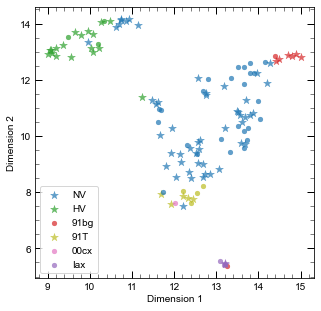

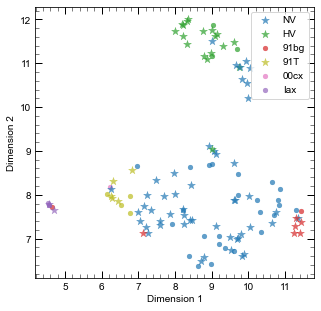

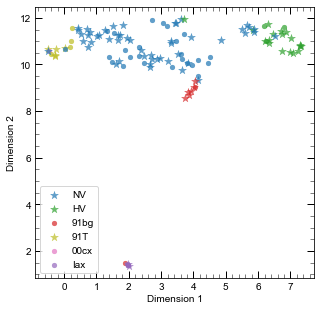

In [13]:
for key in SMOOTHING_SURVEY_KEYS:
    plot_neighbor_survey(key)

## 2. Wavelength window


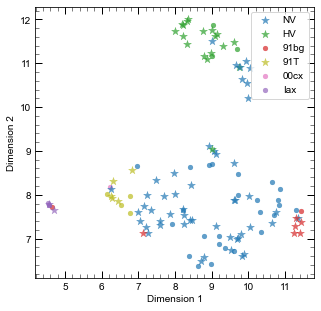

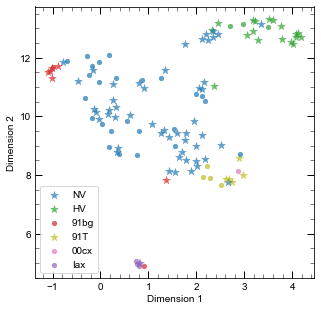

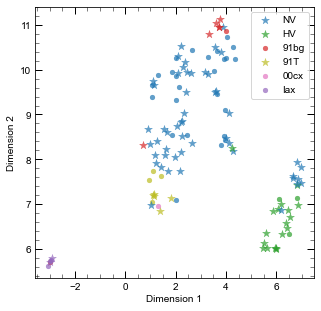

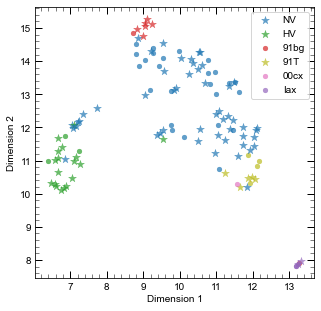

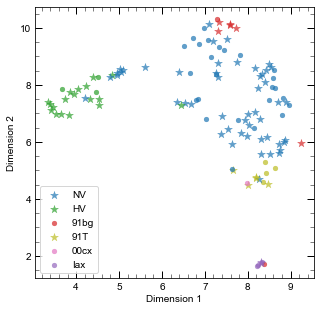

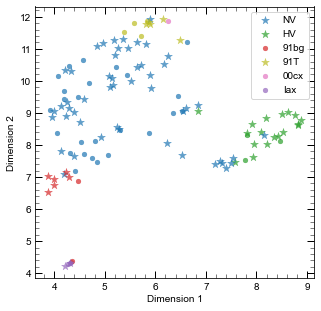

In [14]:
for key in WINDOW_SURVEY_KEYS:
    plot_neighbor_survey(key)

## 3. `n_neighbors` and `random_state`

Other pairs on the baseline table.  Any `n_neighbors` in 2..30 and
`random_state` in 40..58 is in the table.


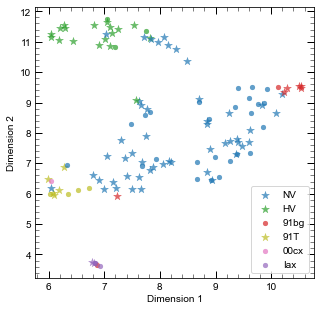

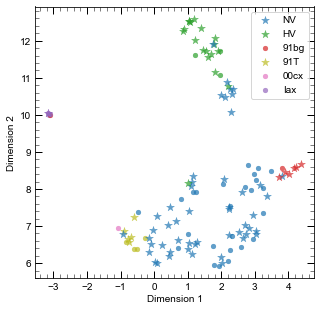

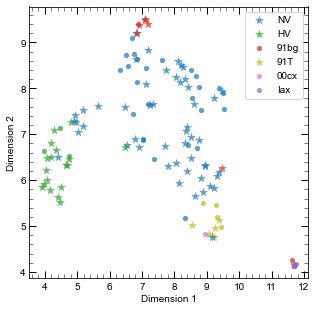

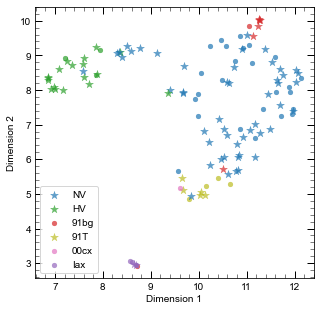

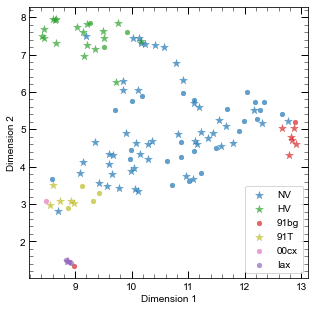

In [15]:
for n_neighbors, random_state in OTHER_NEIGHBOR_SEED_PAIRS:
    plot_neighbor_survey(BASELINE_KEY, n_neighbors, random_state)

## 4. `min_dist` and `metric`


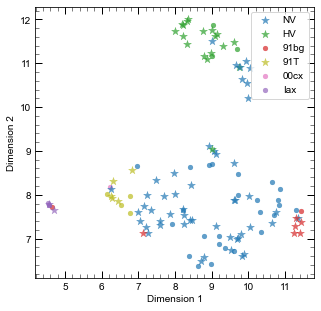

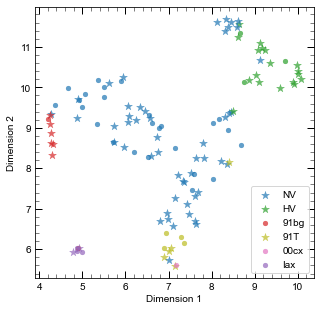

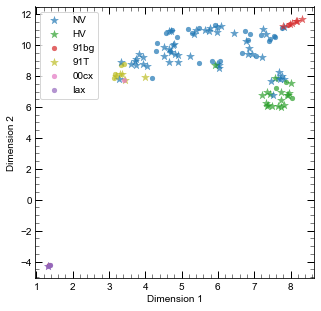

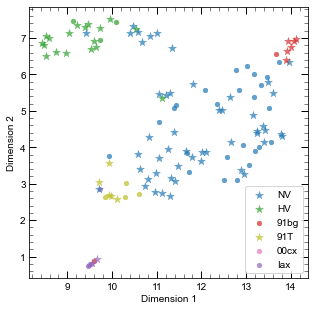

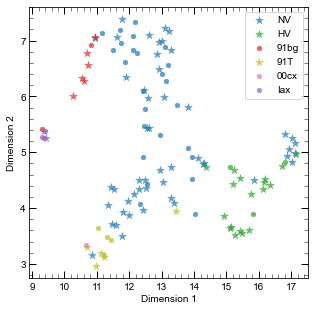

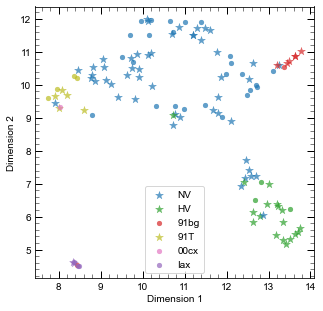

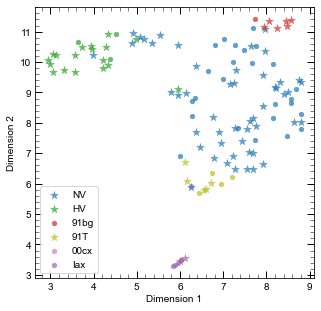

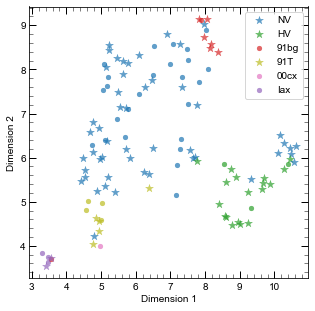

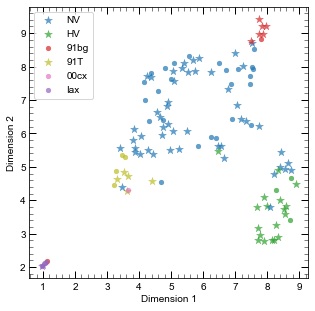

In [16]:
for min_dist in SURVEY_MIN_DISTS:
    for metric in SURVEY_METRICS:
        plot_mindist_metric_survey(min_dist, metric)